## Modelado BetaGeometric NegativeBinominalDistribution

In [2]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes import BetaGeoFitter
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================
# 1. CARGAR DATOS DE VENTAS INDIVIDUALES
# ============================================

df = pd.read_csv("./data/purchases_enriched.csv")
df["InvoiceDate"] = pd.to_datetime(df["event_time"])
df['event_time'] = pd.to_datetime(df['event_time'])

# ============================================
# 2. CALCULAR MÉTRICAS A NIVEL CLIENTE
# ============================================
# Fecha de primera compra por cliente
first_purchase = df.groupby('user_id')['event_time'].min().reset_index()
first_purchase.columns = ['user_id', 'first_purchase_date']

# Fecha de última compra por cliente
last_purchase = df.groupby('user_id')['event_time'].max().reset_index()
last_purchase.columns = ['user_id', 'last_purchase_date']

# Gasto total por cliente (monetary)
monetary = df.groupby('user_id')['price'].sum().reset_index()
monetary.columns = ['user_id', 'monetary']

# Crear customer_df
customer_df = first_purchase.merge(last_purchase, on='user_id')
customer_df = customer_df.merge(monetary, on='user_id')

# Calcular customer_lifetime (días desde primera compra hasta última)
customer_df['customer_lifetime'] = (customer_df['last_purchase_date'] - customer_df['first_purchase_date']).dt.days
customer_df['customer_lifetime'] = customer_df['customer_lifetime'].clip(lower=0)  # Si es 0, dejar como 0

# ============================================
# 3. LIMPIAR OUTLIERS DE MONETARY
# ============================================
customer_df_clean = customer_df.copy()
customer_df_clean = customer_df_clean[customer_df_clean["monetary"] <= customer_df_clean["monetary"].quantile(0.95)]
customer_df_clean = customer_df_clean[customer_df_clean["monetary"] >= customer_df_clean["monetary"].quantile(0.05)]

valid_users = customer_df_clean["user_id"].unique()

# Filtrar también el dataframe original
df = df[df["user_id"].isin(valid_users)].copy()

In [3]:

# Generar tabla resumen por cliente
summary = summary_data_from_transaction_data(
    df,
    customer_id_col="user_id",
    datetime_col="InvoiceDate",
    monetary_value_col="price",
    observation_period_end=df["InvoiceDate"].max()
)

print(summary.sample(5))

           frequency  recency     T  monetary_value
user_id                                            
574293169        0.0      0.0   9.0            0.00
519026793        1.0     35.0  58.0          915.69
570108063        0.0      0.0  17.0            0.00
568558703        1.0     10.0  23.0          177.83
558706953        1.0     19.0  42.0          460.50


In [4]:
summary = summary[summary["frequency"] > 0]
summary

,frequency,recency,T,monetary_value
user_id,,,,
315835135,2.0,11.0,12.0,180.57
340041246,2.0,9.0,56.0,270.11
366237542,1.0,9.0,11.0,173.26
384989212,1.0,14.0,43.0,41.16
403810661,1.0,16.0,19.0,197.02
...,...,...,...,...
579253380,1.0,1.0,1.0,51.48
579255135,1.0,1.0,1.0,335.67
579272231,1.0,1.0,1.0,231.38


In [5]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

print(bgf.summary)

            coef  se(coef)  lower 95% bound  upper 95% bound
r       1.945919  0.008939         1.928398         1.963439
alpha  17.657970  0.111080        17.440253        17.875687
a       0.773667  0.006848         0.760245         0.787090
b       0.690291  0.006844         0.676876         0.703706


In [6]:
t = 30  # días

summary["predicted_purchases_30d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

In [7]:
summary["prob_alive"] = bgf.conditional_probability_alive(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

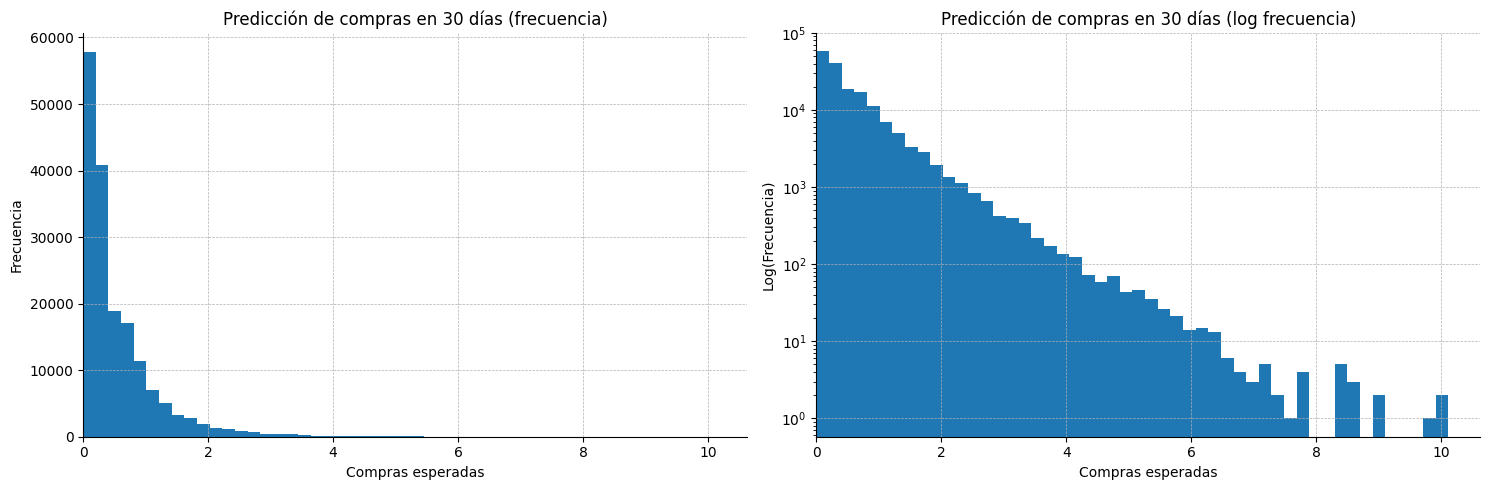

In [9]:
data = summary["predicted_purchases_30d"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# -------------------------
# 1. Frecuencia normal
# -------------------------
ax1.hist(data, bins=50)
ax1.set_title("Predicción de compras en 30 días (frecuencia)")
ax1.set_xlabel("Compras esperadas")
ax1.set_ylabel("Frecuencia")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, linestyle="--", linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# -------------------------
# 2. Frecuencia en escala log
# -------------------------
ax2.hist(data, bins=50)
ax2.set_yscale("log")

ax2.set_title("Predicción de compras en 30 días (log frecuencia)")
ax2.set_xlabel("Compras esperadas")
ax2.set_ylabel("Log(Frecuencia)")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, linestyle="--", linewidth=0.5)
ax2.set_xlim(left=0)

plt.tight_layout()
plt.show()

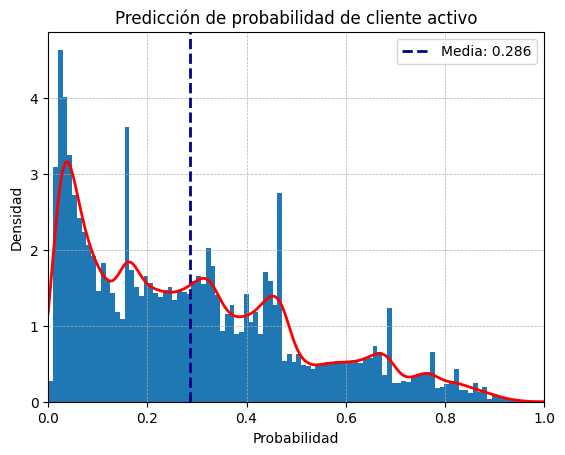

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.figure()

data = summary["prob_alive"].values

# Histograma normalizado
plt.hist(data, bins=100, density=True)

# Media (average)
mean_value = np.mean(data)
plt.axvline(mean_value, color="darkblue", linewidth=2,linestyle="--", label=f"Media: {mean_value:.3f}")

# KDE (curva suavizada)
kde = gaussian_kde(data)
x = np.linspace(0, 1, 200)
plt.plot(x, kde(x), color="red", linewidth=2)

plt.title("Predicción de probabilidad de cliente activo")
plt.xlabel("Probabilidad")
plt.ylabel("Densidad")

plt.grid(True, linestyle="--", linewidth=0.5)
plt.xlim(0, 1)
plt.ylim(bottom=0)
plt.legend()

plt.show()

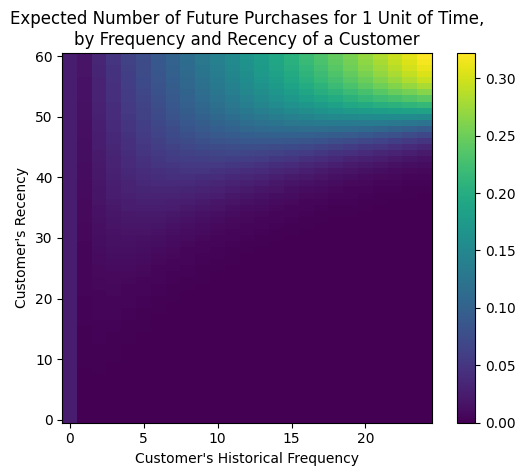

In [11]:

ax = plot_frequency_recency_matrix(bgf)
ax.invert_yaxis()
plt.show()

In [12]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    summary["frequency"],
    summary["monetary_value"]
)

summary["clv_lifetimes"] = ggf.customer_lifetime_value(
    bgf,
    summary["frequency"],
    summary["recency"],
    summary["T"],
    summary["monetary_value"],
    time=3,  # meses
    discount_rate=0.01
)

In [13]:
summary.head()

,frequency,recency,T,monetary_value,predicted_purchases_30d,prob_alive,clv_lifetimes
user_id,,,,,,,
315835135,2.0,11.0,12.0,180.57,1.780874,0.656147,704.126509
340041246,2.0,9.0,56.0,270.11,0.050711,0.038093,34.317336
366237542,1.0,9.0,11.0,173.26,0.835128,0.418935,339.267638
384989212,1.0,14.0,43.0,41.16,0.132276,0.116125,15.291911
403810661,1.0,16.0,19.0,197.02,0.685622,0.409616,328.188191


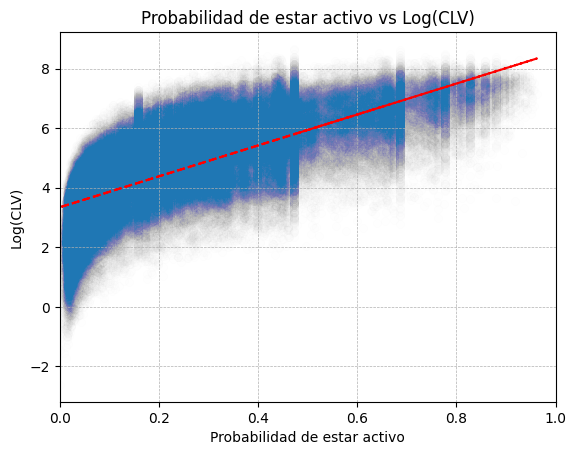

In [14]:

plt.figure()

x = summary["prob_alive"].values

# Evitar problemas con log(0)
y = summary["clv_lifetimes"].values
y_log = np.log(y[y > 0])
x_log = x[y > 0]

plt.scatter(x_log, y_log, alpha=0.005)

# Tendencia (regresión lineal sobre log)
coef = np.polyfit(x_log, y_log, 1)
trend = np.poly1d(coef)
plt.plot(x_log, trend(x_log), linestyle="--", color="red")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

plt.title("Probabilidad de estar activo vs Log(CLV)")
plt.xlabel("Probabilidad de estar activo")
plt.ylabel("Log(CLV)")
plt.xlim(left=0, right=1)

plt.show()

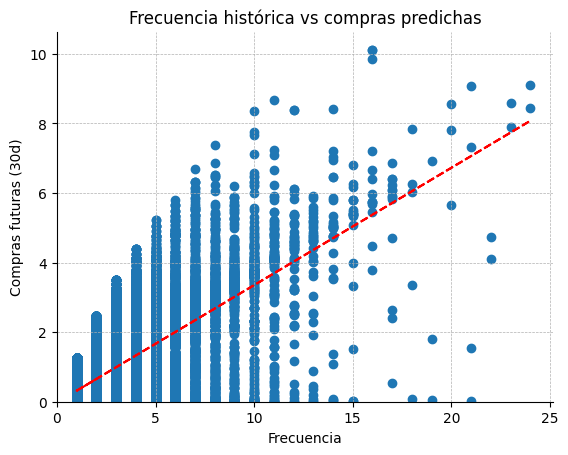

In [15]:
plt.figure()

x = summary["frequency"].values
y = summary["predicted_purchases_30d"].values

plt.scatter(x, y)

# --- Tendencia (regresión lineal) ---
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
plt.plot(x, trend(x), linestyle="--", color="red")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Frecuencia histórica vs compras predichas")
plt.xlabel("Frecuencia")
plt.ylabel("Compras futuras (30d)")
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

<Figure size 640x480 with 0 Axes>

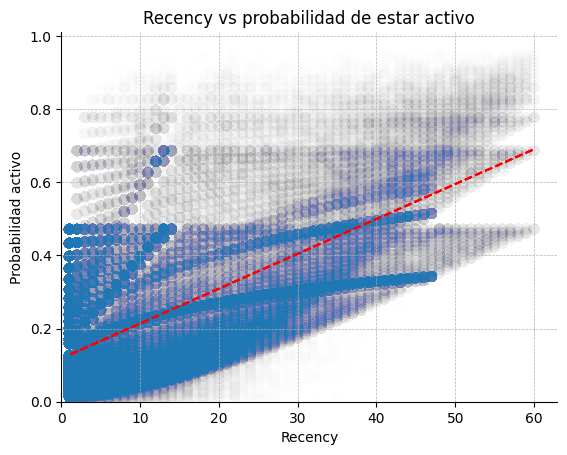

In [16]:
plt.figure()

plt.figure()

x = summary["recency"].values
y = summary["prob_alive"].values

# Scatter con transparencia para ver densidad
plt.scatter(x, y, alpha=0.005, s=72, edgecolors="none")

# Tendencia (regresión lineal)
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
plt.plot(x, trend(x), linestyle="--", color="red")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Recency vs probabilidad de estar activo")
plt.xlabel("Recency")
plt.ylabel("Probabilidad activo")
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

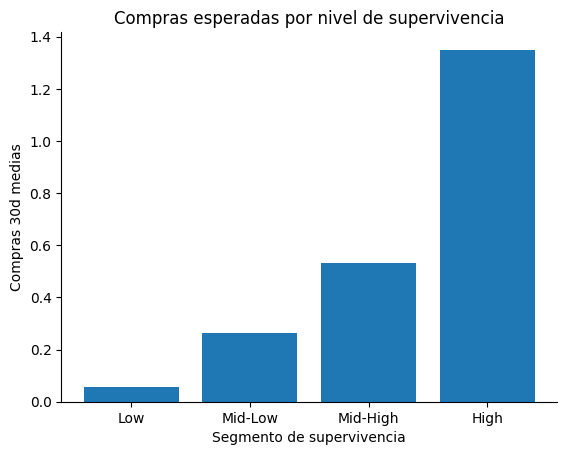

In [17]:
segments = [ "Low", "Mid-Low", "Mid-High", "High"]

summary["alive_segment"] = pd.qcut(
    summary["prob_alive"],
    4,
    labels=segments
)

summary["pred_30d"] = bgf.conditional_expected_number_of_purchases_up_to_time( 
    30, 
    summary["frequency"], 
    summary["recency"], 
    summary["T"] 
)

grouped = summary.groupby("alive_segment")["pred_30d"].mean()

plt.figure()

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.bar(grouped.index.astype(str), grouped.values)

plt.title("Compras esperadas por nivel de supervivencia")
plt.xlabel("Segmento de supervivencia")
plt.ylabel("Compras 30d medias")

plt.show()

In [18]:
corr = summary.corr(numeric_only=True)

print(corr["clv_lifetimes"].sort_values(ascending=False))

clv_lifetimes              1.000000
predicted_purchases_30d    0.639583
pred_30d                   0.639583
prob_alive                 0.616643
monetary_value             0.520814
frequency                  0.379072
recency                    0.274097
T                         -0.197220
Name: clv_lifetimes, dtype: float64


In [19]:
summary["clv_segment"] = pd.qcut(summary["clv_lifetimes"], 4, labels=segments)

print(summary["clv_segment"].value_counts())


clv_segment
Low         43088
Mid-Low     43088
High        43088
Mid-High    43087
Name: count, dtype: int64


In [20]:
segment_analysis = summary.groupby("clv_segment").agg({
    "frequency": "mean",
    "recency": "mean",
    "prob_alive": "mean",
    "predicted_purchases_30d": "mean",
    "monetary_value": "mean"
})

print(segment_analysis)

             frequency    recency  prob_alive  predicted_purchases_30d  \
clv_segment                                                              
Low           1.261859   8.643752    0.090828                 0.121758   
Mid-Low       1.372145  15.652896    0.216898                 0.337813   
Mid-High      1.658110  20.775710    0.334196                 0.585607   
High          2.489139  25.107617    0.500733                 1.157470   

             monetary_value  
clv_segment                  
Low              122.380487  
Mid-Low          200.635362  
Mid-High         275.004295  
High             504.916794  


In [21]:
print("CLV medio:", summary["clv_lifetimes"].mean())
print("CLV mediano:", summary["clv_lifetimes"].median())

print("Probabilidad media de estar activo:", summary["prob_alive"].mean())
print("Compras futuras medias (30d):", summary["predicted_purchases_30d"].mean())

CLV medio: 338.8537997478199
CLV mediano: 142.0008466719765
Probabilidad media de estar activo: 0.28566359005231373
Compras futuras medias (30d): 0.5506617374715842


In [22]:
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

for t in [7, 30, 90]:
    summary[f"pred_{t}d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t,
        summary["frequency"],
        summary["recency"],
        summary["T"]
    )

In [23]:
summary.describe()

,frequency,recency,T,monetary_value,predicted_purchases_30d,prob_alive,clv_lifetimes,pred_30d,pred_7d,pred_90d
count,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000,172351.000000
mean,1.695314,17.544975,37.008552,275.734239,0.550662,0.285664,338.853800,0.680901,0.180887,1.694847
std,1.314115,15.130126,16.384669,283.573091,0.642142,0.218870,484.521670,0.908946,0.242384,2.271236
min,1.000000,1.000000,1.000000,0.830000,0.000960,0.000277,0.072595,0.000258,0.000064,0.000688
25%,1.000000,4.000000,23.000000,90.088864,0.124005,0.093302,41.379293,0.129374,0.033728,0.322708
50%,1.000000,13.000000,40.000000,183.535000,0.344235,0.247211,142.000847,0.339140,0.089521,0.832376
75%,2.000000,28.000000,51.000000,350.621667,0.729122,0.433363,425.624990,0.907734,0.239382,2.255726
max,24.000000,60.000000,60.000000,2418.780000,10.114335,0.962194,5762.145300,14.489475,3.758796,36.708078


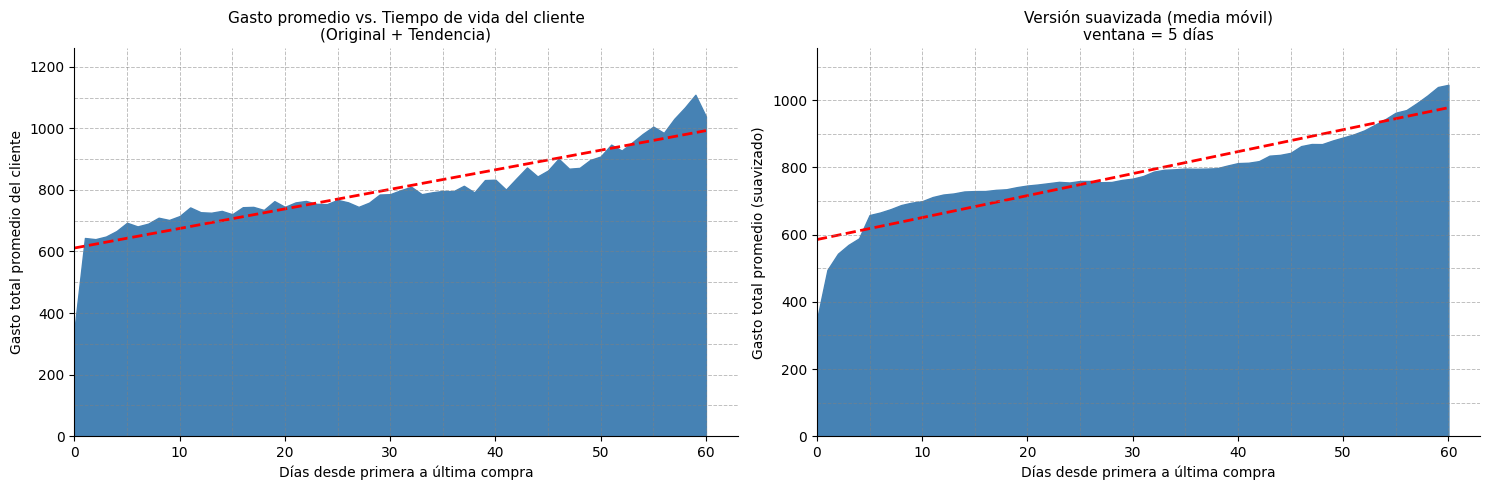


=== ESTADÍSTICAS DE LOS DATOS ===

Número total de transacciones: 1,179,723
Número de clientes únicos: 694,608

Rango de tiempo de vida (días):
  - Mínimo: 0 días
  - Máximo: 60 días
  - Promedio: 5.4 días

Gasto total por cliente:
  - Mínimo: 0.77
  - Máximo: 301617.62
  - Promedio: 696.94


In [24]:
# ============================================
# 1. AGRUPAR POR TIEMPO DE VIDA
# ============================================
grouped = customer_df_clean.groupby("customer_lifetime")["monetary"].mean().reset_index()
grouped = grouped.sort_values("customer_lifetime")

# ============================================
# 2. CALCULAR SUAVIZADO (media móvil)
# ============================================
window = 5
grouped["monetary_smooth"] = grouped["monetary"].rolling(window, min_periods=1).mean()

# ============================================
# 3. TENDENCIAS (regresión lineal)
# ============================================
x = grouped["customer_lifetime"].values
y_raw = grouped["monetary"].values
y_smooth = grouped["monetary_smooth"].values

coef_raw = np.polyfit(x, y_raw, 1)
trend_raw = np.poly1d(coef_raw)

coef_smooth = np.polyfit(x, y_smooth, 1)
trend_smooth = np.poly1d(coef_smooth)

# ============================================
# 4. CREAR GRÁFICOS LADO A LADO
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRÁFICO 1: Original (área + tendencia) ---
ax1.fill_between(x, y_raw, color='steelblue')
ax1.plot(x, trend_raw(x), linestyle="--", color="red", linewidth=2, label='Tendencia lineal')

# Líneas grises de referencia
y_min, y_max = int(y_raw.min()), int(y_raw.max())
x_min, x_max = int(x.min()), int(x.max())

for y_line in range(0, y_max + 100, 100):
    ax1.axhline(y=y_line, linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

for x_line in range(0, x_max + 5, 5):
    ax1.axvline(x=x_line, linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

ax1.set_xlabel("Días desde primera a última compra", fontsize=10)
ax1.set_ylabel("Gasto total promedio del cliente", fontsize=10)
ax1.set_title("Gasto promedio vs. Tiempo de vida del cliente\n(Original + Tendencia)", fontsize=11)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- GRÁFICO 2: Suavizado (media móvil) ---
ax2.fill_between(x, y_smooth, color='steelblue')
ax2.plot(x, trend_smooth(x), linestyle="--", color="red", linewidth=2, label='Tendencia lineal')

# Líneas grises
y_max_smooth = int(y_smooth.max())

for y_line in range(0, y_max_smooth + 100, 100):
    ax2.axhline(y=y_line, linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

for x_line in range(0, x_max + 5, 5):
    ax2.axvline(x=x_line, linestyle="--", linewidth=0.7, color="gray", alpha=0.5)

ax2.set_xlabel("Días desde primera a última compra", fontsize=10)
ax2.set_ylabel("Gasto total promedio (suavizado)", fontsize=10)
ax2.set_title(f"Versión suavizada (media móvil)\nventana = {window} días", fontsize=11)
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================
# 5. (OPCIONAL) ESTADÍSTICAS DESCRIPTIVAS
# ============================================
print("\n=== ESTADÍSTICAS DE LOS DATOS ===\n")
print(f"Número total de transacciones: {len(df):,}")
print(f"Número de clientes únicos: {customer_df['user_id'].nunique():,}")
print(f"\nRango de tiempo de vida (días):")
print(f"  - Mínimo: {customer_df['customer_lifetime'].min()} días")
print(f"  - Máximo: {customer_df['customer_lifetime'].max()} días")
print(f"  - Promedio: {customer_df['customer_lifetime'].mean():.1f} días")
print(f"\nGasto total por cliente:")
print(f"  - Mínimo: {customer_df['monetary'].min():.2f}")
print(f"  - Máximo: {customer_df['monetary'].max():.2f}")
print(f"  - Promedio: {customer_df['monetary'].mean():.2f}")

In [25]:
customer_df_clean["clv_segment"] = pd.qcut(
    customer_df_clean["monetary"],
    q=4,
    labels= segments
)

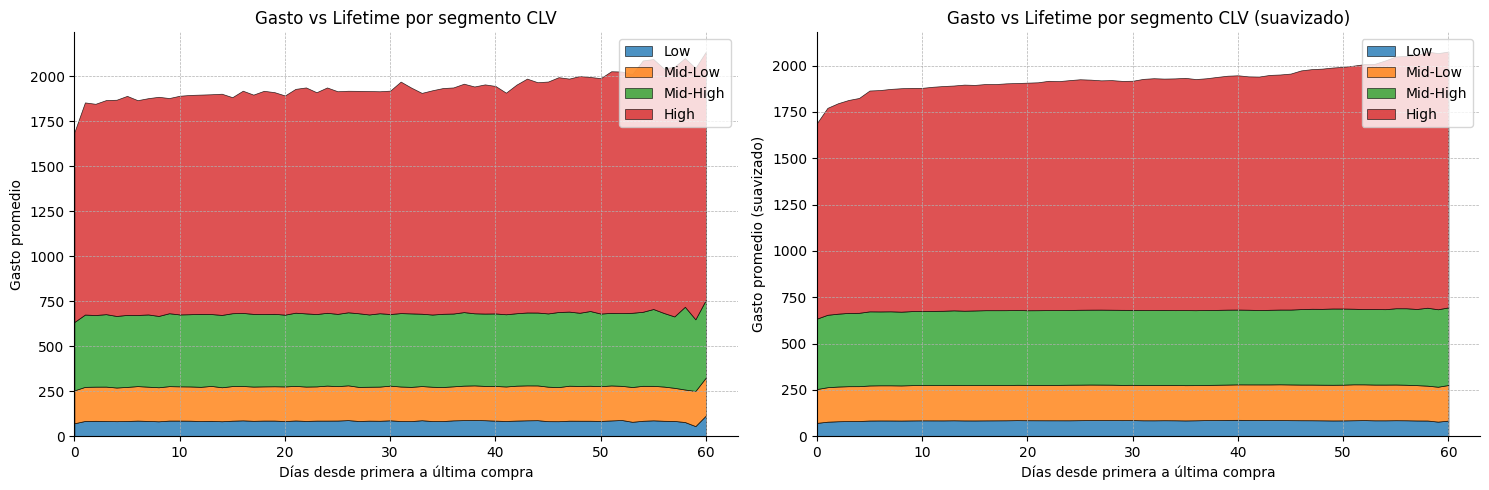

In [26]:
grouped_seg = (
    customer_df_clean
    .groupby(["customer_lifetime", "clv_segment"])["monetary"]
    .mean()
    .reset_index()
)
window = 5

grouped_seg["monetary_smooth"] = (
    grouped_seg
    .sort_values("customer_lifetime")
    .groupby("clv_segment")["monetary"]
    .transform(lambda x: x.rolling(window, min_periods=1).mean())
)


# Preparar datos para stackplot
def preparar_stackplot(data, x_col, y_col, segment_col):
    pivot_data = data.pivot(index=x_col, columns=segment_col, values=y_col).fillna(0)
    # Reordenar columnas según prioridad
    pivot_data = pivot_data[segments]
    return pivot_data.index.values, [pivot_data[col].values for col in pivot_data.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Primer gráfico - stackplot
x1, y1_list = preparar_stackplot(grouped_seg, "customer_lifetime", "monetary", "clv_segment")
ax1.stackplot(x1, *y1_list, labels=segments, alpha=0.8, edgecolor='black', linewidth=0.5)

ax1.set_xlabel("Días desde primera a última compra")
ax1.set_ylabel("Gasto promedio")
ax1.set_title("Gasto vs Lifetime por segmento CLV")
ax1.legend(loc='upper right')
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, linestyle="--", linewidth=0.5)

# Segundo gráfico - stackplot
x2, y2_list = preparar_stackplot(grouped_seg, "customer_lifetime", "monetary_smooth", "clv_segment")
ax2.stackplot(x2, *y2_list, labels=segments, alpha=0.8, edgecolor='black', linewidth=0.5)

ax2.set_xlabel("Días desde primera a última compra")
ax2.set_ylabel("Gasto promedio (suavizado)")
ax2.set_title(f"Gasto vs Lifetime por segmento CLV (suavizado)")
ax2.legend(loc='upper right')
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

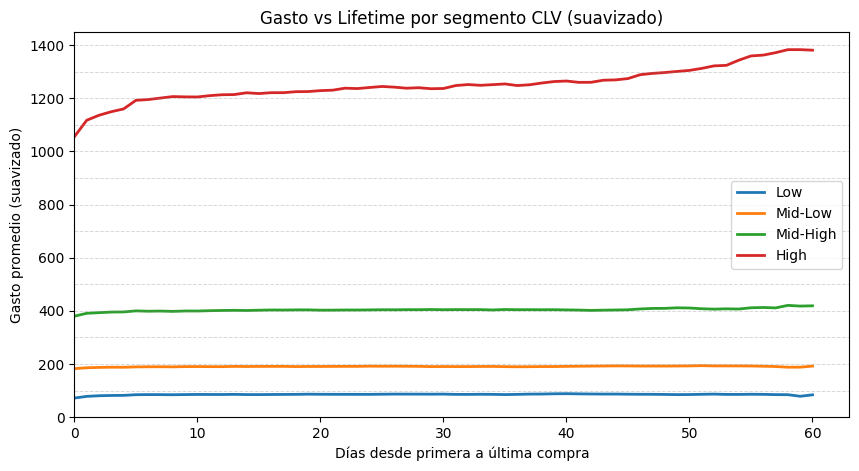

In [27]:
plt.figure(figsize=(10, 5))

for segment in grouped_seg["clv_segment"].unique():
    data_seg = grouped_seg[grouped_seg["clv_segment"] == segment]

    x = data_seg["customer_lifetime"]
    y = data_seg["monetary_smooth"]

    plt.plot(x, y, linewidth=2, label=segment)

plt.xlabel("Días desde primera a última compra")
plt.ylabel("Gasto promedio (suavizado)")
plt.title(f"Gasto vs Lifetime por segmento CLV (suavizado)")
plt.legend()
plt.xlim(left=0)
plt.ylim(bottom=0)

for y_line in range(0, int(grouped_seg["monetary_smooth"].max()) + 100, 100):
    plt.axhline(y=y_line, linestyle="--", linewidth=0.7, color="gray", alpha=0.3)

plt.show()

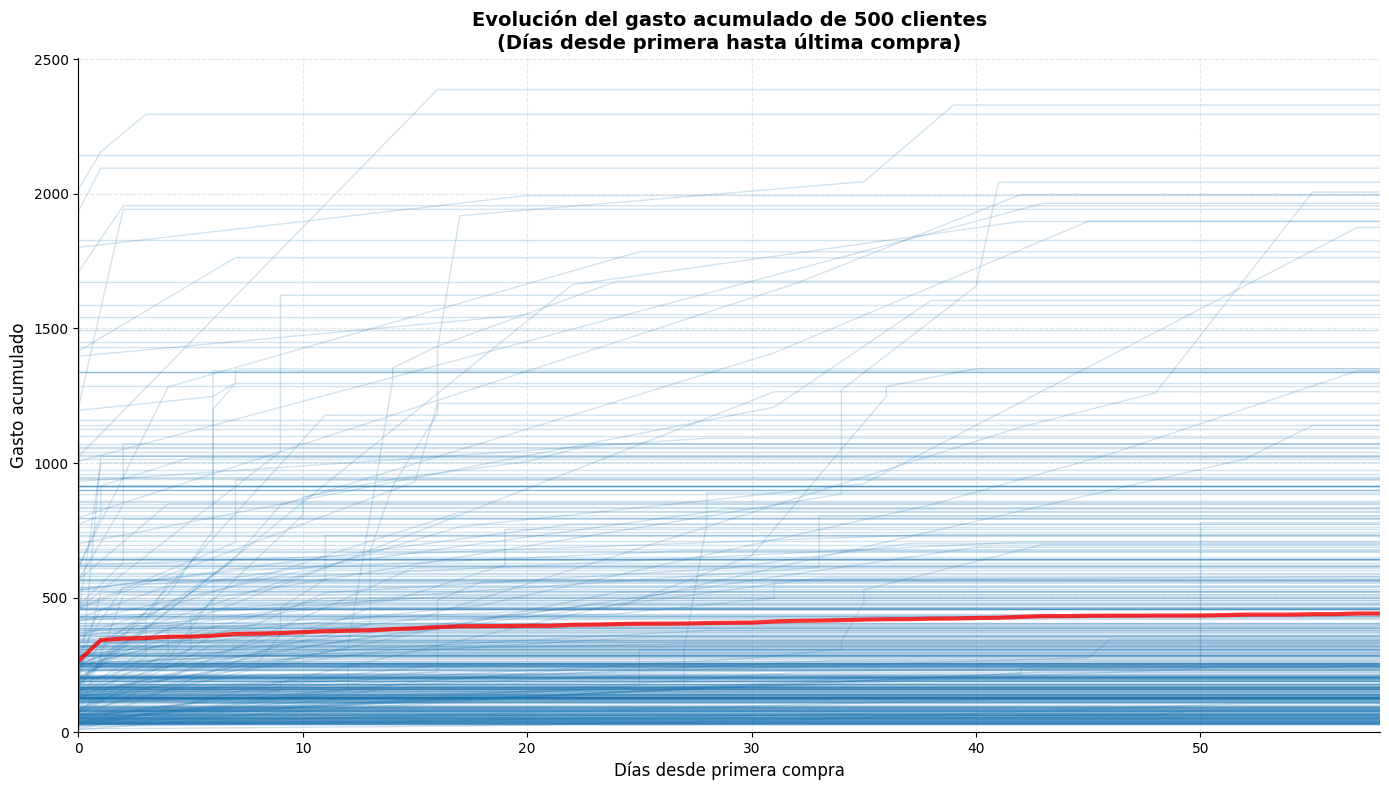


ESTADÍSTICAS DE LOS 50 CLIENTES SELECCIONADOS
Número de clientes seleccionados: 500
Total de transacciones en la muestra: 920
Día máximo considerado en el gráfico: 58

Estadísticas de tiempo de vida (días):
count    500.000000
mean       5.240000
std       12.255398
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       58.000000
Name: customer_lifetime, dtype: float64

Estadísticas de gasto total por cliente:
count     500.000000
mean      441.198960
std       465.803523
min        31.530000
25%       128.442500
50%       256.605000
75%       581.002500
max      2386.970000
Name: monetary, dtype: float64


In [28]:
# ============================================
# 1. SELECCIONAR 50 CLIENTES ALEATORIOS
# ============================================
np.random.seed(123) 
random_customers = customer_df_clean.sample(n=min(500, len(customer_df_clean)), random_state=123)

# ============================================
# 2. CREAR DATAFRAME DE COMPRAS PARA CLIENTES SELECCIONADOS
# ============================================
# Filtrar compras de los clientes aleatorios
random_purchases = df[df['user_id'].isin(random_customers['user_id'])].copy()

# Ordenar por cliente y fecha
random_purchases = random_purchases.sort_values(['user_id', 'event_time'])

# Calcular días desde primera compra para cada transacción
random_purchases['days_from_first'] = random_purchases.groupby('user_id')['event_time'].transform(
    lambda x: (x - x.min()).dt.days
)

# Calcular gasto acumulado por cliente
random_purchases['cumulative_spend'] = random_purchases.groupby('user_id')['price'].cumsum()

# ============================================
# 3. CREAR GRÁFICO DE LÍNEAS: GASTO ACUMULADO vs DÍAS
# ============================================
fig, ax = plt.subplots(figsize=(14, 8))

# Color único para todas las líneas
line_color = '#1f77b4'
max_day = random_purchases['days_from_first'].max()

# Graficar línea para cada cliente
for idx, (user_id, user_data) in enumerate(random_purchases.groupby('user_id')):
    # Datos originales del cliente
    days = user_data['days_from_first'].values
    spends = user_data['cumulative_spend'].values
    
    # Extender la línea hasta el día máximo
    last_day = days[-1]
    last_spend = spends[-1]
    
    if last_day < max_day:
        # Añadir punto final en el día máximo
        days_extended = np.append(days, max_day)
        spends_extended = np.append(spends, last_spend)
    else:
        days_extended = days
        spends_extended = spends
    
    # Graficar línea del cliente
    ax.plot(days_extended, 
            spends_extended, 
            alpha=0.2, 
            linewidth=1.0,
            color=line_color,
            label=f'Cliente {user_id}' if idx < 10 else "")  # Mostrar solo primeros 10 en leyenda

# Personalizar gráfico
ax.set_xlabel("Días desde primera compra", fontsize=12)
ax.set_ylabel("Gasto acumulado", fontsize=12)
ax.set_title(f"Evolución del gasto acumulado de {len(random_customers)} clientes\n(Días desde primera hasta última compra)", 
             fontsize=14, fontweight='bold')
ax.set_xlim(left=0, right=max_day)
ax.set_ylim(bottom=0)

# Añadir grid para mejor legibilidad
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Mejorar spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Añadir línea de tendencia media
avg_curve = []
for day in range(max_day + 1):
    day_spends = []
    for user_id, user_data in random_purchases.groupby('user_id'):
        if day <= user_data['days_from_first'].max():
            # Interpolar el gasto acumulado en ese día
            user_data_sorted = user_data.sort_values('days_from_first')
            if day in user_data_sorted['days_from_first'].values:
                spend = user_data_sorted[user_data_sorted['days_from_first'] == day]['cumulative_spend'].iloc[0]
            else:
                # Buscar el valor más cercano anterior
                prev_days = user_data_sorted[user_data_sorted['days_from_first'] <= day]
                if len(prev_days) > 0:
                    spend = prev_days['cumulative_spend'].iloc[-1]
                else:
                    spend = 0
            day_spends.append(spend)
        else:
            # Si el cliente ya no tiene datos, usar su último gasto acumulado
            user_data_sorted = user_data.sort_values('days_from_first')
            spend = user_data_sorted['cumulative_spend'].iloc[-1]
            day_spends.append(spend)
    
    if day_spends:
        avg_curve.append(np.mean(day_spends))
    else:
        avg_curve.append(0)

ax.plot(range(max_day + 1), avg_curve, color='red', linewidth=3, 
        label=f'Tendencia promedio ({len(random_customers)} clientes)', 
        linestyle='-', alpha=0.8)

# Añadir una línea vertical tenue para marcar el final del período de datos
ax.axvline(x=max_day, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

# ============================================
# 4. ESTADÍSTICAS DESCRIPTIVAS DE LA MUESTRA
# ============================================
print("\n" + "="*60)
print("ESTADÍSTICAS DE LOS 50 CLIENTES SELECCIONADOS")
print("="*60)
print(f"Número de clientes seleccionados: {len(random_customers)}")
print(f"Total de transacciones en la muestra: {len(random_purchases)}")
print(f"Día máximo considerado en el gráfico: {max_day}")
print(f"\nEstadísticas de tiempo de vida (días):")
print(random_customers['customer_lifetime'].describe())
print(f"\nEstadísticas de gasto total por cliente:")
print(random_customers['monetary'].describe())

Estadísticas descriptivas

In [29]:
print("\n=== ESTADÍSTICAS DE LOS DATOS ===\n")
print(f"Número total de transacciones: {len(df):,}")
print(f"Número de clientes únicos: {customer_df['user_id'].nunique():,}")
print(f"\nRango de tiempo de vida (días):")
print(f"  - Mínimo: {customer_df['customer_lifetime'].min()} días")
print(f"  - Máximo: {customer_df['customer_lifetime'].max()} días")
print(f"  - Promedio: {customer_df['customer_lifetime'].mean():.1f} días")
print(f"\nGasto total por cliente:")
print(f"  - Mínimo: {customer_df['monetary'].min():.2f}")
print(f"  - Máximo: {customer_df['monetary'].max():.2f}")
print(f"  - Promedio: {customer_df['monetary'].mean():.2f}")


=== ESTADÍSTICAS DE LOS DATOS ===

Número total de transacciones: 1,179,723
Número de clientes únicos: 694,608

Rango de tiempo de vida (días):
  - Mínimo: 0 días
  - Máximo: 60 días
  - Promedio: 5.4 días

Gasto total por cliente:
  - Mínimo: 0.77
  - Máximo: 301617.62
  - Promedio: 696.94


In [30]:
# =========================================================
# 1. VALOR SEMANAL HISTÓRICO
# =========================================================

df["week"] = df["event_time"].dt.to_period("W").apply(lambda r: r.start_time)
weekly_revenue = df.groupby("week")["price"].sum().sort_index()
weekly_hist_clv = weekly_revenue.cumsum()

# =========================================================
# 2. FORECAST 4 SEMANAS
# =========================================================

summary["pred_28d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    28,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["expected_monetary"] = ggf.conditional_expected_average_profit( 
    summary["frequency"], 
    summary["monetary_value"] 
) 
summary["clv_30d"] = summary["pred_30d"] * summary["expected_monetary"]

expected_weekly_clv = (
    summary["pred_28d"].sum() * summary["expected_monetary"].mean() / 4
)

last_week = weekly_hist_clv.index.max()

future_weeks = pd.date_range(
    start=last_week + pd.Timedelta(weeks=1),
    periods=4,
    freq="W"
)

future_clv = np.array([
    weekly_hist_clv.iloc[-1] + expected_weekly_clv * (i + 1)
    for i in range(4)
])

weekly_full = pd.concat([
    weekly_hist_clv,
    pd.Series(future_clv, index=future_weeks)
])



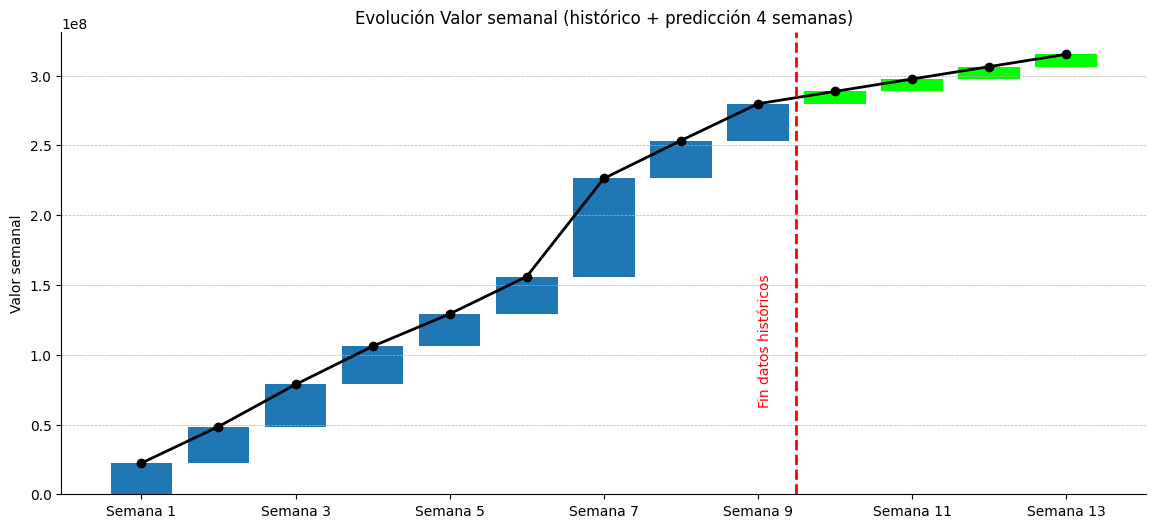

In [31]:
# =========================================================
# 3. WATERFALL
# =========================================================

labels = [f"Semana {i+1}" for i in range(len(weekly_full))]
values = weekly_full.values

split_idx = len(weekly_hist_clv)


plt.figure(figsize=(14, 6))

hist_color = "C0"
future_color = "lime"

# barras acumuladas como waterfall
for i in range(len(values)):
    if i == 0:
        plt.bar(labels[i], values[i], color=hist_color)
    else:
        delta = values[i] - values[i - 1]

        # separar histórico vs predicción
        if i < split_idx:
            color = hist_color
        else:
            color = future_color

        plt.bar(
            labels[i],
            delta,
            bottom=values[i - 1],
            color=color
        )

# línea acumulada
plt.plot(labels, values, color="black", marker="o", linewidth=2)
step = 2  

plt.xticks(
    ticks=np.arange(0, len(labels), step),
    labels=np.array(labels)[::step],
    rotation=0
)
# línea separadora histórico vs forecast
plt.axvline(x=split_idx - 0.5, color="red", linestyle="--", linewidth=2)

plt.text(
    split_idx - 1,
    max(values) * 0.5,
    "Fin datos históricos",
    rotation=90,
    verticalalignment="top",
    color="red"
)

plt.title("Evolución Valor semanal (histórico + predicción 4 semanas)")
plt.ylabel("Valor semanal")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, axis="y")

plt.xticks(rotation=0)

plt.show()

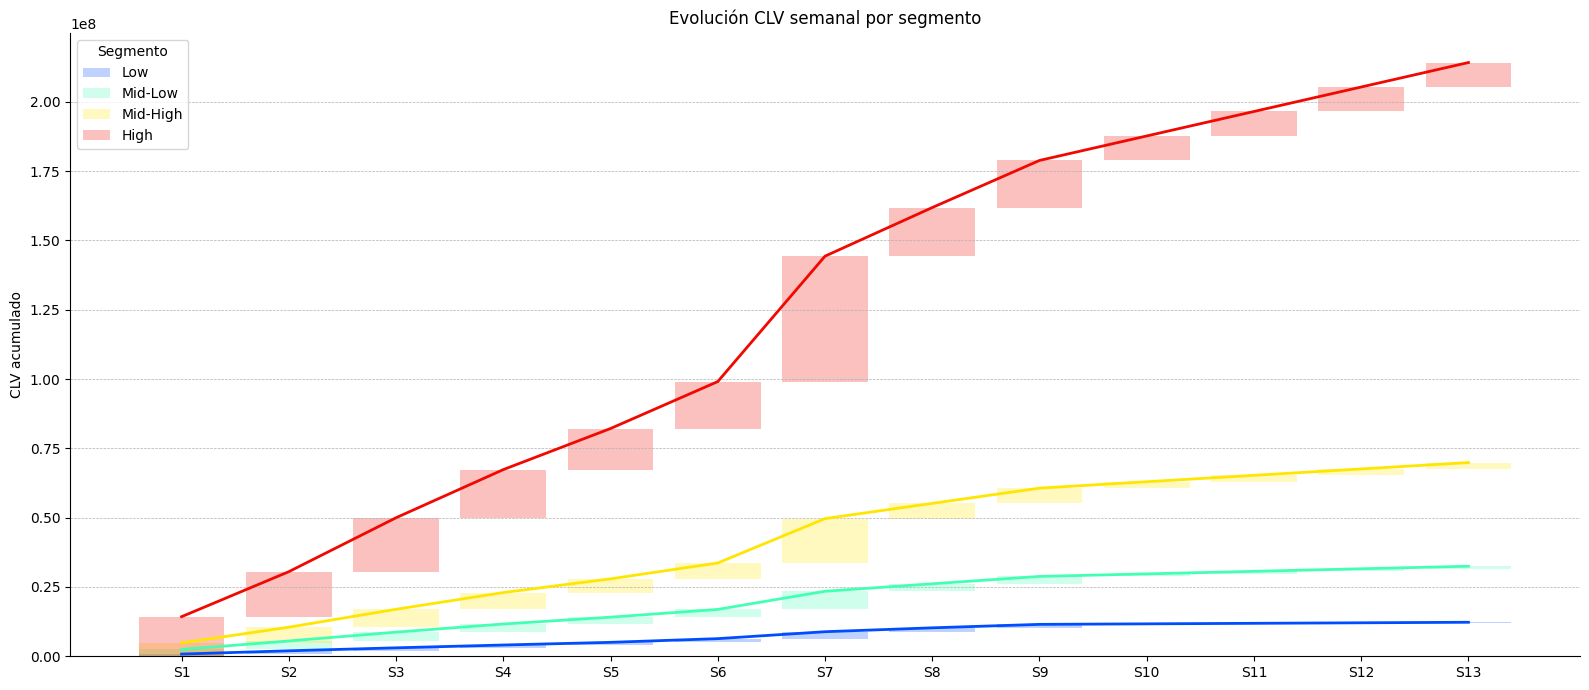

In [32]:
# =========================================================
# 1. CLV HISTÓRICO SEMANAL
# =========================================================
weekly_segment = (
    df.merge(
        customer_df_clean[["user_id", "clv_segment"]],
        on="user_id",
        how="inner"
    )
    .groupby(["week", "clv_segment"])["price"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 7))

# =========================================================
# 2. WATERFALL POR SEGMENTO
# =========================================================
# colormap base
cmap = plt.cm.jet

# generar colores uniformemente espaciados
colors = cmap(np.linspace(0.2, 0.9, len(segments)))

# diccionario segmento -> color
segment_colors = {
    segment: color
    for segment, color in zip(segments, colors)
}

for segment in segments:

    color = segment_colors[segment]
    seg_df = (
        weekly_segment[weekly_segment["clv_segment"] == segment]
        .sort_values("week")
    )

    weekly_clv = seg_df.groupby("week")["price"].sum().cumsum()

    # =====================================================
    # FORECAST 4 SEMANAS
    # =====================================================

    seg_summary = summary[summary["clv_segment"] == segment]

    expected_weekly_clv = (
        seg_summary["pred_28d"].sum()
        * seg_summary["expected_monetary"].mean()
        / 4
    )

    last_week = weekly_clv.index.max()

    future_weeks = pd.date_range(
        start=last_week + pd.Timedelta(weeks=1),
        periods=4,
        freq="W"
    )

    future_values = np.array([
        weekly_clv.iloc[-1] + expected_weekly_clv * (i + 1)
        for i in range(4)
    ])

    full_series = pd.concat([
        weekly_clv,
        pd.Series(future_values, index=future_weeks)
    ])

    values = full_series.values

    labels = [f"S{i+1}" for i in range(len(values))]

    # =====================================================
    # WATERFALL
    # =====================================================

    for i in range(len(values)):

        if i == 0:
            plt.bar(
                labels[i],
                values[i],
                color=color,
                alpha=0.25,
                label=segment
            )

        else:
            plt.bar(
                labels[i],
                values[i] - values[i - 1],
                bottom=values[i - 1],
                color=color,
                alpha=0.25
            )

    # línea acumulada
    plt.plot(
        labels,
        values,
        color=color,
        linewidth=2
    )

# =========================================================
# 3. ESTILO
# =========================================================

plt.title("Evolución CLV semanal por segmento")
plt.ylabel("CLV acumulado")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(True, linestyle="--", linewidth=0.5, axis="y")

plt.legend(title="Segmento")

plt.tight_layout()
plt.show()

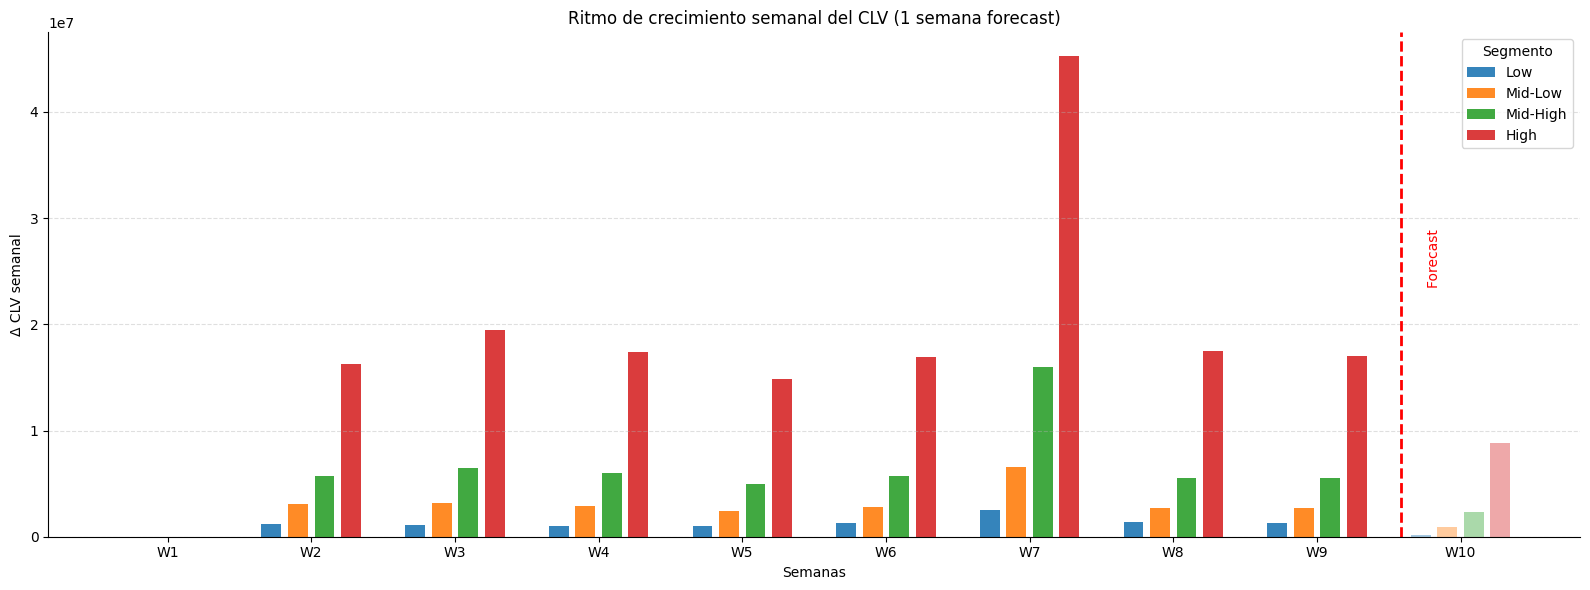

In [33]:

# =========================================================
# 1. CRECIMIENTO HISTÓRICO + FORECAST (1 semana)
# =========================================================
colors = {s: plt.cm.tab10(i) for i, s in enumerate(segments)}

all_growth = {}
hist_len = 0

for seg in segments:

    seg_df = weekly_segment[weekly_segment["clv_segment"] == seg].sort_values("week")

    weekly_clv = seg_df.groupby("week")["price"].sum().cumsum()
    growth_hist = weekly_clv.diff().fillna(0).values

    seg_summary = summary[summary["clv_segment"] == seg]

    expected_weekly = (
        seg_summary["pred_28d"].sum()
        * seg_summary["expected_monetary"].mean()
        / 4
    )

    # SOLO 1 SEMANA DE FORECAST
    forecast = np.array([expected_weekly])

    full = np.concatenate([growth_hist, forecast])

    all_growth[seg] = full
    hist_len = max(hist_len, len(growth_hist))

# =========================================================
# 2. PLOT AGRUPADO CON ESPACIADO
# =========================================================

max_len = max(len(v) for v in all_growth.values())

x = np.arange(max_len) * 1.3  # espaciado semanas

bar_width = 0.18

offsets = np.linspace(
    -bar_width * len(segments) / 2,
    bar_width * len(segments) / 2,
    len(segments)
)

plt.figure(figsize=(16, 6))

for i, seg in enumerate(segments):

    values = all_growth[seg]

    if len(values) < max_len:
        values = np.pad(values, (0, max_len - len(values)))

    # separar color histórico vs forecast
    hist_part = len(values) - 1

    plt.bar(
        x[:hist_part] + offsets[i],
        values[:hist_part],
        width=bar_width,
        color=colors[seg],
        alpha=0.9,
        label=seg
    )

    # forecast (1 semana)
    plt.bar(
        x[hist_part] + offsets[i],
        values[hist_part],
        width=bar_width,
        color=colors[seg],
        alpha=0.4
    )

# =========================================================
# 3. SEPARACIÓN HISTÓRICO / FORECAST
# =========================================================

split_x = (max_len - 1) * 1.3

plt.axvline(
    x=split_x - bar_width * 3,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.text(
    split_x - 0.3,
    plt.ylim()[1] * 0.5,
    "Forecast ",
    rotation=90,
    color="red"
)

# =========================================================
# 4. ESTILO
# =========================================================

plt.title("Ritmo de crecimiento semanal del CLV (1 semana forecast)")
plt.ylabel("Δ CLV semanal")
plt.xlabel("Semanas")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(True, linestyle="--", axis="y", alpha=0.4)

plt.xticks(x, [f"W{i+1}" for i in range(max_len)], rotation=0)

plt.legend(title="Segmento")

plt.tight_layout()
plt.show()

In [34]:
# ==========================================================
# 1. CREAR DATASET CALIBRATION / HOLDOUT
# ==========================================================
# calibration_period_end:
# fecha donde "cortamos" entrenamiento
#
# observation_period_end:
# fecha final disponible en datos

summary_cal_holdout = calibration_and_holdout_data(
    transactions=df,
    customer_id_col='user_id',
    datetime_col="InvoiceDate",
    monetary_value_col='price',
    calibration_period_end=df["InvoiceDate"].quantile(0.70),
    observation_period_end=df["InvoiceDate"].max(),
    freq='D'
)

print(summary_cal_holdout.head())

           frequency_cal  recency_cal  T_cal  monetary_value_cal  \
user_id                                                            
138340325            0.0          0.0    6.0                 0.0   
225644257            0.0          0.0    5.0                 0.0   
253299396            0.0          0.0   11.0                 0.0   
264649825            0.0          0.0   42.0                 0.0   
267316896            0.0          0.0    3.0                 0.0   

           frequency_holdout  monetary_value_holdout  duration_holdout  
user_id                                                                 
138340325                0.0                     0.0              13.0  
225644257                0.0                     0.0              13.0  
253299396                0.0                     0.0              13.0  
264649825                0.0                     0.0              13.0  
267316896                0.0                     0.0              13.0  


In [35]:
summary_cal_holdout = summary_cal_holdout[
    summary_cal_holdout["frequency_cal"] > 0
]
bgf = BetaGeoFitter(penalizer_coef=0.01)

bgf.fit(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)


ggf.fit(
    summary_cal_holdout["frequency_cal"],
    summary_cal_holdout["monetary_value_cal"]
)

summary_cal_holdout["clv_holdout"] = (
    summary_cal_holdout["frequency_holdout"] *
    summary_cal_holdout["monetary_value_holdout"]
)

summary_cal_holdout["pred_clv"] = (
    bgf.predict(
        30,
        summary_cal_holdout["frequency_cal"],
        summary_cal_holdout["recency_cal"],
        summary_cal_holdout["T_cal"]
    )
    *
    ggf.conditional_expected_average_profit(
        summary_cal_holdout["frequency_cal"],
        summary_cal_holdout["monetary_value_cal"]
    )
)

# Predicción compras siguientes 30 días
summary_cal_holdout['pred_holdout_purchases'] = (
    bgf.predict(
        30,
        summary_cal_holdout['frequency_cal'],
        summary_cal_holdout['recency_cal'],
        summary_cal_holdout['T_cal']
    )
)
summary_cal_holdout = summary_cal_holdout.merge(
    summary[["clv_segment"]],
    left_index=True,
    right_index=True,
    how="left"
)

In [36]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

mae = mean_absolute_error(
    summary_cal_holdout["clv_holdout"],
    summary_cal_holdout["pred_clv"]
)



rmse = np.sqrt(mean_squared_error(
    summary_cal_holdout["clv_holdout"],
    summary_cal_holdout["pred_clv"]
))



r2 = r2_score(
    summary_cal_holdout["clv_holdout"],
    summary_cal_holdout["pred_clv"]
)
summary_cal_holdout["clv_rank_pred"] = summary_cal_holdout["pred_clv"].rank(ascending=False)
summary_cal_holdout["clv_rank_real"] = summary_cal_holdout["clv_holdout"].rank(ascending=False)

corr = summary_cal_holdout[["clv_holdout", "pred_clv"]].corr().iloc[0, 1]

spearman = spearmanr(
    summary_cal_holdout["clv_rank_pred"],
    summary_cal_holdout["clv_rank_real"]
).correlation

In [37]:
print("\n=== MÉTRICAS DEL BG NBD CLV Holdout/Pred ===\n")

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")
print(f"Pearson corr: {corr:.3f}")
print(f"Spearman corr: {spearman:.3f}")


=== MÉTRICAS DEL BG NBD CLV Holdout/Pred ===

MAE: 164.26
RMSE: 289.82
R2: -1.883
Pearson corr: 0.099
Spearman corr: 0.159


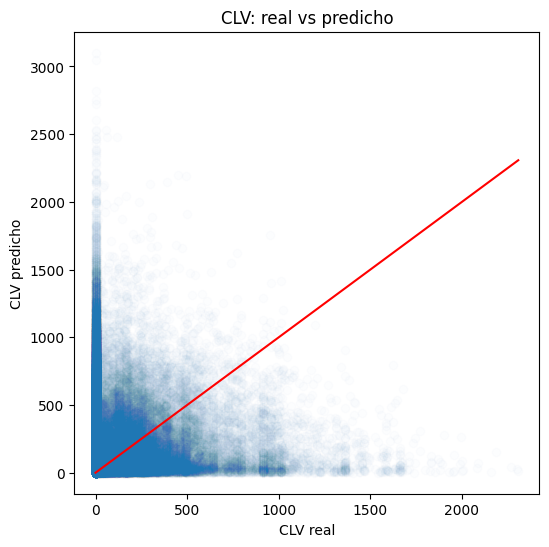

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(
    summary_cal_holdout["clv_holdout"],
    summary_cal_holdout["pred_clv"],
    alpha=0.01
)

plt.plot([0, max(summary_cal_holdout["clv_holdout"])],
         [0, max(summary_cal_holdout["clv_holdout"])],
         color="red")

plt.xlabel("CLV real")
plt.ylabel("CLV predicho")
plt.title("CLV: real vs predicho")

plt.show()

In [39]:
def metrics(group):
    return pd.Series({
        "MAE": mean_absolute_error(group["clv_holdout"], group["pred_clv"]),
        "RMSE": np.sqrt(mean_squared_error(group["clv_holdout"], group["pred_clv"])),
        "R2": group[["clv_holdout", "pred_clv"]].corr().iloc[0,1],
        "Spearman": group["clv_holdout"].corr(group["pred_clv"], method="spearman"),
        "Pearson": group["clv_holdout"].corr(group["pred_clv"], method="pearson")
    })

segment_metrics = summary_cal_holdout.groupby("clv_segment").apply(metrics,include_groups=False)
print("\n=== MÉTRICAS DEL BG NBD por segmento CLV ===\n")

print(segment_metrics)


=== MÉTRICAS DEL BG NBD por segmento CLV ===

                    MAE        RMSE        R2  Spearman   Pearson
clv_segment                                                      
Low           16.262547   20.722513 -0.032801 -0.042364 -0.032801
Mid-Low       80.579238   91.650446 -0.271782 -0.344254 -0.271782
Mid-High     217.419410  256.047835 -0.494513 -0.656628 -0.494513
High         453.812481  575.605982 -0.400479 -0.579237 -0.400479


In [40]:
def metrics_purchases(group):
    return pd.Series({
        "MAE": mean_absolute_error(group["frequency_holdout"], group["pred_holdout_purchases"]),
        "RMSE": np.sqrt(mean_squared_error(group["frequency_holdout"], group["pred_holdout_purchases"])),
        "Spearman": group["frequency_holdout"].corr(group["pred_holdout_purchases"], method="spearman"),
        "Pearson": group["frequency_holdout"].corr(group["pred_holdout_purchases"])
    })

purchase_metrics = summary_cal_holdout.groupby("clv_segment").apply(metrics_purchases,include_groups=False)

print(purchase_metrics)

                  MAE      RMSE  Spearman   Pearson
clv_segment                                        
Low          0.186709  0.292224  0.052803  0.085317
Mid-Low      0.462829  0.605233  0.011015  0.023590
Mid-High     0.787511  0.975780 -0.200008 -0.121411
High         1.067547  1.383400 -0.122449  0.037961


In [41]:
y_true = summary_cal_holdout['frequency_holdout']
y_pred = summary_cal_holdout['pred_holdout_purchases']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]
spearman = spearmanr(y_true, y_pred)[0]


print("\n=== MÉTRICAS BG/NBD Frequency Holdout/Pred Holdout Purchases ===\n")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")
print(f"Pearson corr: {corr:.3f}")
print(f"Spearman corr: {spearman:.3f}")


=== MÉTRICAS BG/NBD Frequency Holdout/Pred Holdout Purchases ===

MAE: 0.56
RMSE: 0.84
R2: -0.386
Pearson corr: 0.267
Spearman corr: 0.228


In [42]:
mean_real = y_true.mean()

relative_error = (mae / mean_real) * 100

print(f"\nCompras reales medias: {mean_real:.4f}")
print(f"Error relativo medio: {relative_error:.2f}%")


Compras reales medias: 0.3004
Error relativo medio: 187.15%


In [43]:
corr = np.corrcoef(y_true, y_pred)[0,1]

print(f"\nCorrelación real vs predicho: {corr:.4f}")


Correlación real vs predicho: 0.2672


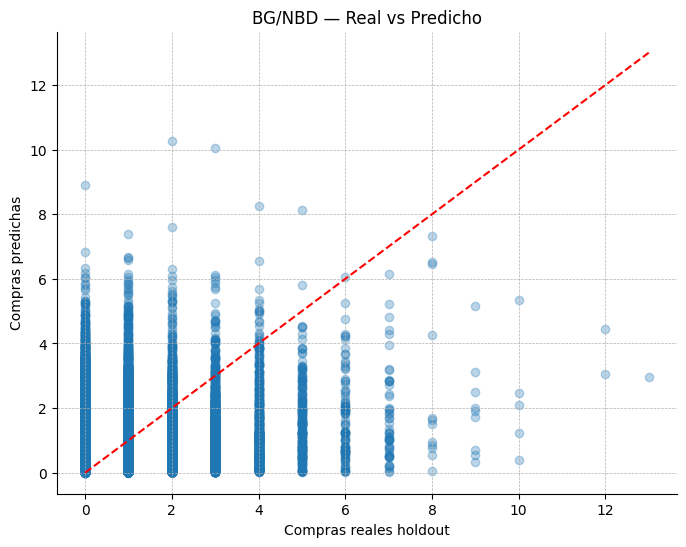

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.3
)

# línea perfecta
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle='--',
    color='red',
)

plt.xlabel("Compras reales holdout")
plt.ylabel("Compras predichas")
plt.title("BG/NBD — Real vs Predicho")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

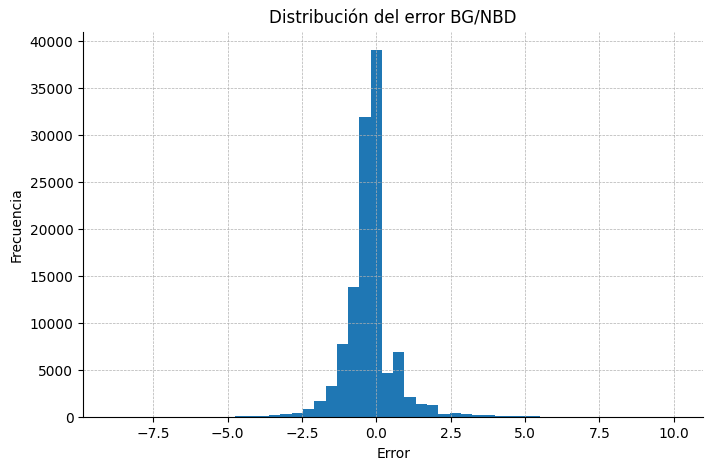

In [45]:
summary_cal_holdout['error'] = (
    y_true - y_pred
)

plt.figure(figsize=(8,5))

plt.hist(
    summary_cal_holdout['error'],
    bins=50
)

plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución del error BG/NBD")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

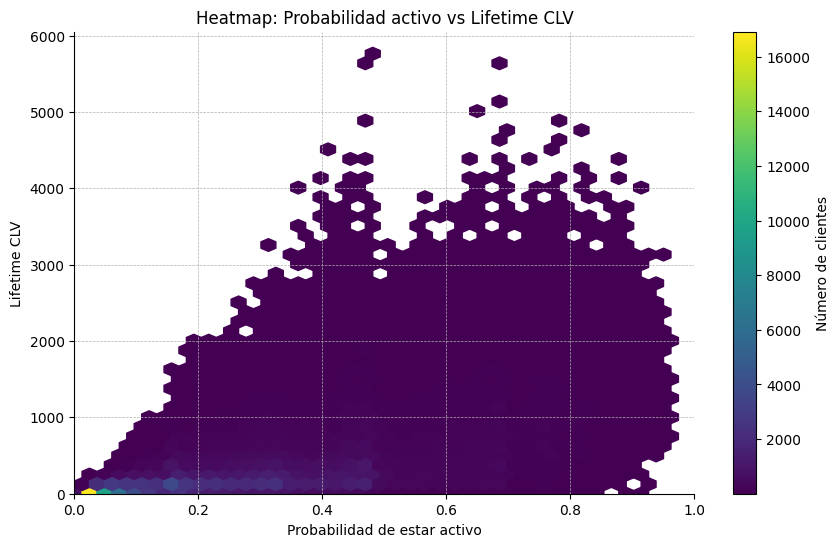

In [55]:
plt.figure(figsize=(10, 6))

# heatmap 2D
hb = plt.hexbin(
    summary["prob_alive"],
    summary["clv_lifetimes"],
    gridsize=40,
    mincnt=1
)

# colorbar
cb = plt.colorbar(hb)
cb.set_label("Número de clientes")

# títulos
plt.title("Heatmap: Probabilidad activo vs Lifetime CLV")
plt.xlabel("Probabilidad de estar activo")
plt.ylabel("Lifetime CLV")

# límites
plt.xlim(0, 1)
plt.ylim(bottom=0)

# grid
plt.grid(True, linestyle="--", linewidth=0.5)

# quitar spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

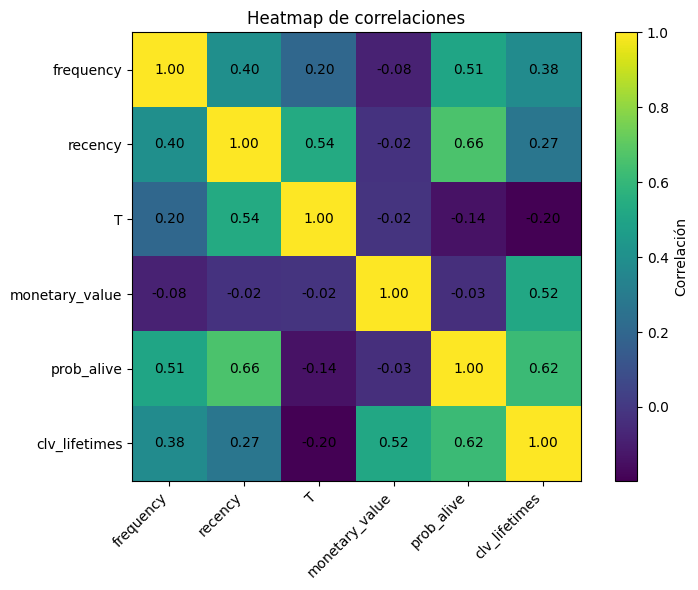

In [56]:
# ============================================
# HEATMAP DE CORRELACIONES
# ============================================


# variables a incluir
corr_vars = [
    "frequency",
    "recency",
    "T",
    "monetary_value",
    "prob_alive",
    "clv_lifetimes"
]

# matriz de correlación
corr_matrix = summary[corr_vars].corr()

# figura
plt.figure(figsize=(8, 6))

# heatmap
im = plt.imshow(corr_matrix)

# colorbar
cbar = plt.colorbar(im)
cbar.set_label("Correlación")

# labels
plt.xticks(
    range(len(corr_vars)),
    corr_vars,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_vars)),
    corr_vars
)

# valores dentro de las celdas
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# título
plt.title("Heatmap de correlaciones")

# layout
plt.tight_layout()

plt.show()